# 00 · EDA — 문제 정의 (FruitsFamily 유동성 위기)

**문제:** 빈티지 1점물 C2C에서 매물 대부분이 안 팔린다. 그런데 플랫폼은
전 셀러에게 동일한 일반 안내("사진 많이, 설명 길게")만 준다 — 이 노트북은
그 일반 안내가 데이터와 충돌함을 보인다 (가격대 통제 후에도).

결과변수: `is_sold` (매칭 성공). 속도 아님 — 연령으로도 안 팔리는 매물이 다수.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "AppleGothic"   # macOS 한글 폰트
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CACHE = ROOT / "data" / "cache"
FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

lst = pd.read_parquet(CACHE / "features_listing.parquet")
sel = pd.read_parquet(CACHE / "features_seller.parquet")
print("listing:", lst.shape, "| seller:", sel.shape)
print("전체 전환율:", f"{lst['is_sold'].mean():.1%}")

listing: (284654, 27) | seller: (11095, 16)
전체 전환율: 21.5%


## 1. 유동성 위기 — 5개 중 4개는 안 팔린다, 시간도 못 푼다

연령이 쌓여도 전환율은 ~23%에서 정체 → *속도*가 아니라 **매칭** 문제.

            mean    size
age_bucket              
0-7d        16.3    7904
7-30d       18.7   47863
30-90d      21.8   69731
90-365d     23.1  103703
365d+       21.5   55453

전체 미판매율: 78.5%
미판매 중 90일+ 방치: 55.2%


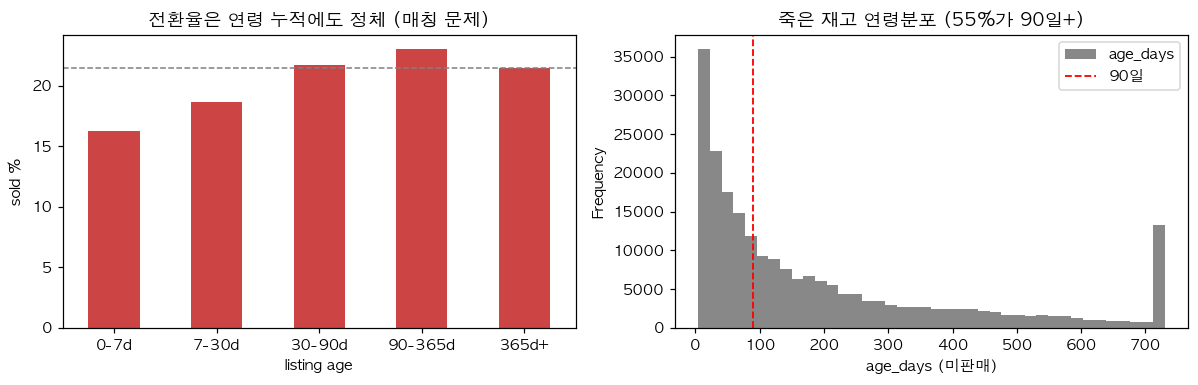

In [2]:
bins = [0, 7, 30, 90, 365, np.inf]
labels = ["0-7d", "7-30d", "30-90d", "90-365d", "365d+"]
lst["age_bucket"] = pd.cut(lst["age_days"], bins=bins, labels=labels, right=False)
by_age = lst.groupby("age_bucket", observed=True)["is_sold"].agg(["mean", "size"])
print(by_age.assign(mean=lambda d: (d["mean"]*100).round(1)))

dead = lst[lst["is_sold"] == 0]
dead90 = (dead["age_days"] > 90).mean()
print(f"\n전체 미판매율: {1-lst['is_sold'].mean():.1%}")
print(f"미판매 중 90일+ 방치: {dead90:.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
(by_age["mean"]*100).plot(kind="bar", ax=ax[0], color="#c44", rot=0)
ax[0].set(title="전환율은 연령 누적에도 정체 (매칭 문제)", ylabel="sold %", xlabel="listing age")
ax[0].axhline(lst["is_sold"].mean()*100, ls="--", c="gray", lw=1)
dead["age_days"].clip(upper=730).plot(kind="hist", bins=40, ax=ax[1], color="#888")
ax[1].axvline(90, c="red", ls="--", lw=1.2, label="90일")
ax[1].set(title=f"죽은 재고 연령분포 ({dead90:.0%}가 90일+)", xlabel="age_days (미판매)")
ax[1].legend()
fig.tight_layout(); fig.savefig(FIG / "eda_liquidity.png", bbox_inches="tight"); plt.show()

## 2. 셀러 불평등 — 16%는 단 한 건도 못 판다

zero-sale 셀러: 15.9%
상위 10% 셀러가 전체 판매의 31.4% 차지


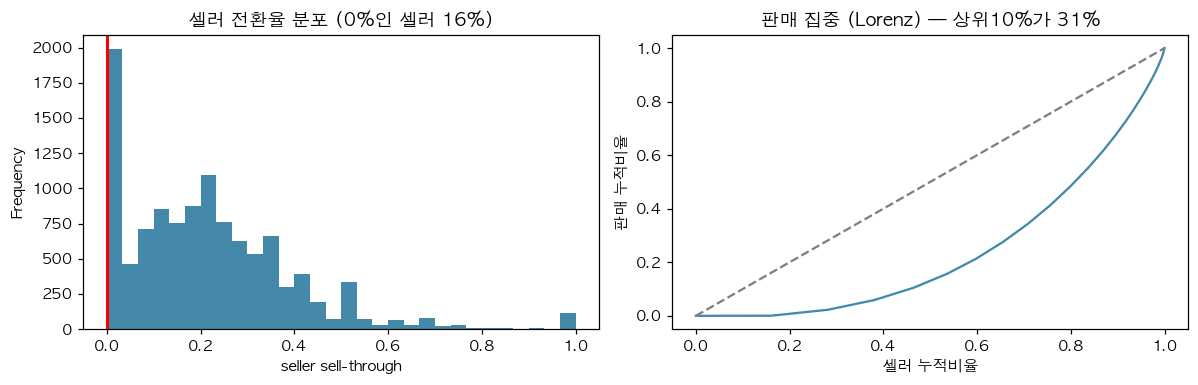

In [3]:
zero = (sel["n_sold"] == 0).mean()
sold_sorted = np.sort(sel["n_sold"].values)[::-1]
top10_share = sold_sorted[:int(len(sel)*0.1)].sum() / sold_sorted.sum()
print(f"zero-sale 셀러: {zero:.1%}")
print(f"상위 10% 셀러가 전체 판매의 {top10_share:.1%} 차지")

# Lorenz curve
cum = np.cumsum(np.sort(sel["n_sold"].values)) / sel["n_sold"].sum()
x = np.linspace(0, 1, len(cum))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sel["sell_through"].plot(kind="hist", bins=30, ax=ax[0], color="#48a")
ax[0].axvline(0, c="red", lw=2)
ax[0].set(title=f"셀러 전환율 분포 (0%인 셀러 {zero:.0%})", xlabel="seller sell-through")
ax[1].plot(x, cum, color="#48a"); ax[1].plot([0,1],[0,1], ls="--", c="gray")
ax[1].set(title=f"판매 집중 (Lorenz) — 상위10%가 {top10_share:.0%}", xlabel="셀러 누적비율", ylabel="판매 누적비율")
fig.tight_layout(); fig.savefig(FIG / "eda_inequality.png", bbox_inches="tight"); plt.show()

## 3. 핵심 모순 — 일반 안내가 데이터와 충돌 (가격대 통제 후에도)

"사진 많이"는 전 가격대에서 **역방향**, "설명 길게"도 마찬가지.
단, 이건 raw 상관 — 역선택(안 팔릴 매물에 노력 집중) 가능성을 H1/H2에서 분리한다.

사진수 구간 × 가격대 전환율:
photo_grp     ≤2   3-5    6+
price_tier                  
1_low<3만    23.7  19.8  17.8
2_mid<8만    27.0  21.0  17.1
3_high<20만  28.3  23.2  20.0
4_top20만+   24.6  21.8  18.6


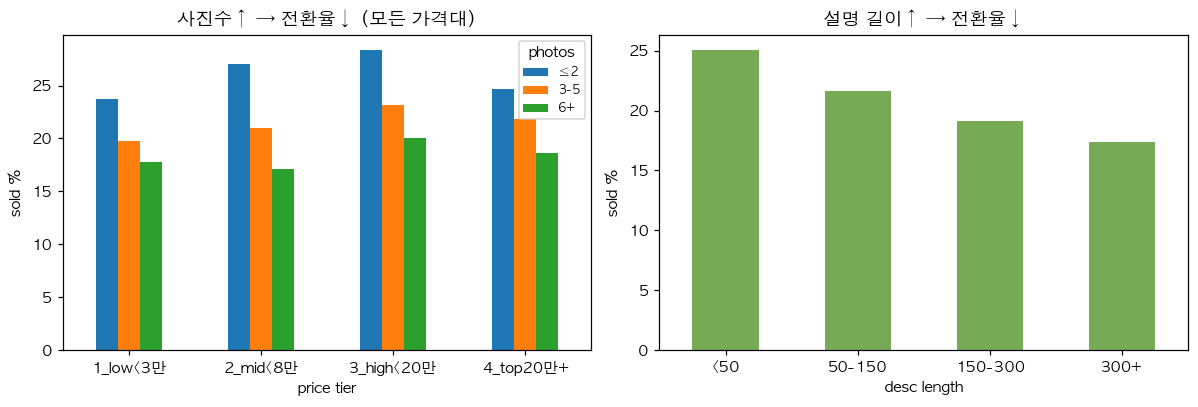

In [4]:
lst["photo_grp"] = pd.cut(lst["n_photos"], [-1, 2, 5, 10], labels=["≤2", "3-5", "6+"])
lst["desc_grp"] = pd.cut(lst["desc_len"], [-1, 50, 150, 300, np.inf],
                         labels=["<50", "50-150", "150-300", "300+"])

print("사진수 구간 × 가격대 전환율:")
piv = lst.pivot_table("is_sold", "price_tier", "photo_grp", observed=True)
print((piv*100).round(1))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
(piv*100).plot(kind="bar", ax=ax[0], rot=0)
ax[0].set(title="사진수↑ → 전환율↓ (모든 가격대)", ylabel="sold %", xlabel="price tier")
ax[0].legend(title="photos", fontsize=8)
(lst.groupby("desc_grp", observed=True)["is_sold"].mean()*100).plot(
    kind="bar", ax=ax[1], rot=0, color="#7a5")
ax[1].set(title="설명 길이↑ → 전환율↓", ylabel="sold %", xlabel="desc length")
fig.tight_layout(); fig.savefig(FIG / "eda_paradox.png", bbox_inches="tight"); plt.show()

## 4. 계획서 EDA 수치와 대조 (sanity) + results 저장

In [5]:
summary = {
    "n_listings": int(len(lst)),
    "n_sellers": int(len(sel)),
    "overall_sell_through": round(float(lst["is_sold"].mean()), 4),
    "unsold_pct": round(float(1 - lst["is_sold"].mean()), 4),
    "dead_stock_90d_pct": round(float(dead90), 4),
    "zero_sale_seller_pct": round(float(zero), 4),
    "top10pct_sales_share": round(float(top10_share), 4),
    "sold_by_age_bucket": {k: round(v*100, 1) for k, v in by_age["mean"].items()},
    "sold_by_photo_grp": {str(k): round(v*100, 1) for k, v in
                          lst.groupby("photo_grp", observed=True)["is_sold"].mean().items()},
}
print(json.dumps(summary, ensure_ascii=False, indent=2))
(ROOT / "results").mkdir(exist_ok=True)
(ROOT / "results" / "eda.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("\n계획서 기대: 미판매 78.8% / zero-sale 15.9% / top10 31.4% / ≤2장 최고")

{
  "n_listings": 284654,
  "n_sellers": 11095,
  "overall_sell_through": 0.2151,
  "unsold_pct": 0.7849,
  "dead_stock_90d_pct": 0.5519,
  "zero_sale_seller_pct": 0.1589,
  "top10pct_sales_share": 0.3144,
  "sold_by_age_bucket": {
    "0-7d": 16.3,
    "7-30d": 18.7,
    "30-90d": 21.8,
    "90-365d": 23.1,
    "365d+": 21.5
  },
  "sold_by_photo_grp": {
    "≤2": 26.4,
    "3-5": 21.9,
    "6+": 18.7
  }
}

계획서 기대: 미판매 78.8% / zero-sale 15.9% / top10 31.4% / ≤2장 최고
